## SARIMA

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns', 'sector_index']]
fin_data

,date,weighted_sector_returns,sector_index
0,2017-01-03,0.000000,100.000000
1,2017-01-04,0.353432,100.353432
2,2017-01-05,-0.182223,100.170565
3,2017-01-06,1.397196,101.570144
4,2017-01-09,3.645896,105.273286
...,...,...,...
2258,2026-07-13,-0.746327,2695.019313
2259,2026-07-14,0.906947,2719.461701
2260,2026-07-15,0.779799,2740.668037
2261,2026-07-16,1.505893,2781.939574


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
 2   sector_index             2263 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 53.2 KB


In [4]:
from pmdarima import auto_arima

# Fit the optimal auto_arima model
model = auto_arima(
    y=fin_data['weighted_sector_returns'], # Your time series data
    start_p=1, start_q=1,   # Initial guesses for p and q
    max_p=5, max_q=5,       # Maximum bounds for searching p and q
    seasonal=True,          # Enable support for seasonal data (SARIMA)
    m=12,                   # Period for seasonal differencing (e.g., 12 for monthly data)
    stepwise=True,          # Uses an intelligent stepwise algorithm for speed
    trace=True              # Prints feedback on the grid search progress
)

# Summarize the selected model attributes
print(model.summary())

# # Forecast the next 10 steps
# forecast = model.predict(n_periods=10)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=8502.255, Time=4.90 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=8566.583, Time=0.10 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=8499.644, Time=0.95 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=8498.450, Time=1.29 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=8587.143, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=8497.589, Time=0.28 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=8498.434, Time=0.91 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=8500.400, Time=3.88 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=8499.435, Time=0.79 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=8499.430, Time=0.45 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=8498.703, Time=0.35 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=8501.586, Time=0.87 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=8512.345, Time=0.13 sec

Best model:  ARIMA(0,0,1)(0,0,0)[12] intercept
Total fit time: 15.173 seconds
       

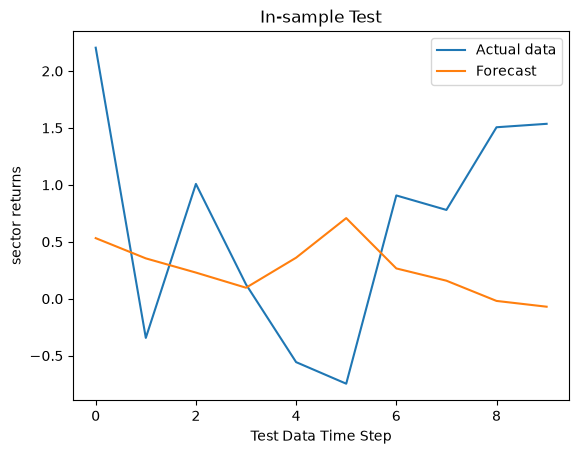

R² Score: -0.42404069608881834
RMSE: 1.1203603400940916
MAE: 0.9944255122227593


In [8]:
# Fitting a SARIMA(0,0,1)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(1,1,1), 
seasonal_order=(1,1,1,52))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

We wiil be back. Set seasonality to 5. Since this is a daily data. It will capture weekly information. It could have been 7 but stock data excludes weekends